In [28]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [29]:
data = {
    "Day": ["D1", "D2", "D3", "D4", "D5", "D6", "D7", "D8", "D9", "D10", "D11", "D12", "D13", "D14"],
    "Outlook": ["Sunny", "Sunny", "Overcast", "Rain", "Rain", "Rain", "Overcast", "Sunny", "Sunny", "Rain", "Sunny", "Overcast", "Overcast", "Rain"],
    "Temp": ["Hot", "Hot", "Hot", "Mild", "Cool", "Cool", "Cool", "Mild", "Cool", "Mild", "Mild", "Mild", "Hot", "Mild"],
    "Humidity": ["High", "High", "High", "High", "Normal", "Normal", "Normal", "High", "Normal", "Normal", "Normal", "High", "Normal", "High"],
    "Wind": ["Weak", "Strong", "Weak", "Weak", "Weak", "Strong", "Strong", "Weak", "Weak", "Weak", "Strong", "Strong", "Weak", "Strong"],
    "Play": ["No", "No", "Yes", "Yes", "Yes", "No", "Yes", "No", "Yes", "Yes", "Yes", "Yes", "Yes", "No"]
}

df = pd.DataFrame(data)
df.head(5)

,Day,Outlook,Temp,Humidity,Wind,Play
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No
2,D3,Overcast,Hot,High,Weak,Yes
3,D4,Rain,Mild,High,Weak,Yes
4,D5,Rain,Cool,Normal,Weak,Yes


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Day       14 non-null     object
 1   Outlook   14 non-null     object
 2   Temp      14 non-null     object
 3   Humidity  14 non-null     object
 4   Wind      14 non-null     object
 5   Play      14 non-null     object
dtypes: object(6)
memory usage: 804.0+ bytes


In [31]:
df.describe()

,Day,Outlook,Temp,Humidity,Wind,Play
count,14,14,14,14,14,14
unique,14,3,3,2,2,2
top,D1,Sunny,Mild,High,Weak,Yes
freq,1,5,6,7,8,9


In [32]:
X = df.drop(['Day', 'Play'], axis=1)
y = df['Play']

In [33]:
# one hot Encoding the features
X = pd.get_dummies(X)
print(X)

    Outlook_Overcast  Outlook_Rain  Outlook_Sunny  Temp_Cool  Temp_Hot  \
0              False         False           True      False      True   
1              False         False           True      False      True   
2               True         False          False      False      True   
3              False          True          False      False     False   
4              False          True          False       True     False   
5              False          True          False       True     False   
6               True         False          False       True     False   
7              False         False           True      False     False   
8              False         False           True       True     False   
9              False          True          False      False     False   
10             False         False           True      False     False   
11              True         False          False      False     False   
12              True         False    

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [35]:
# Train the dataset tree classifier
model = DecisionTreeClassifier(criterion='gini', max_depth=3)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

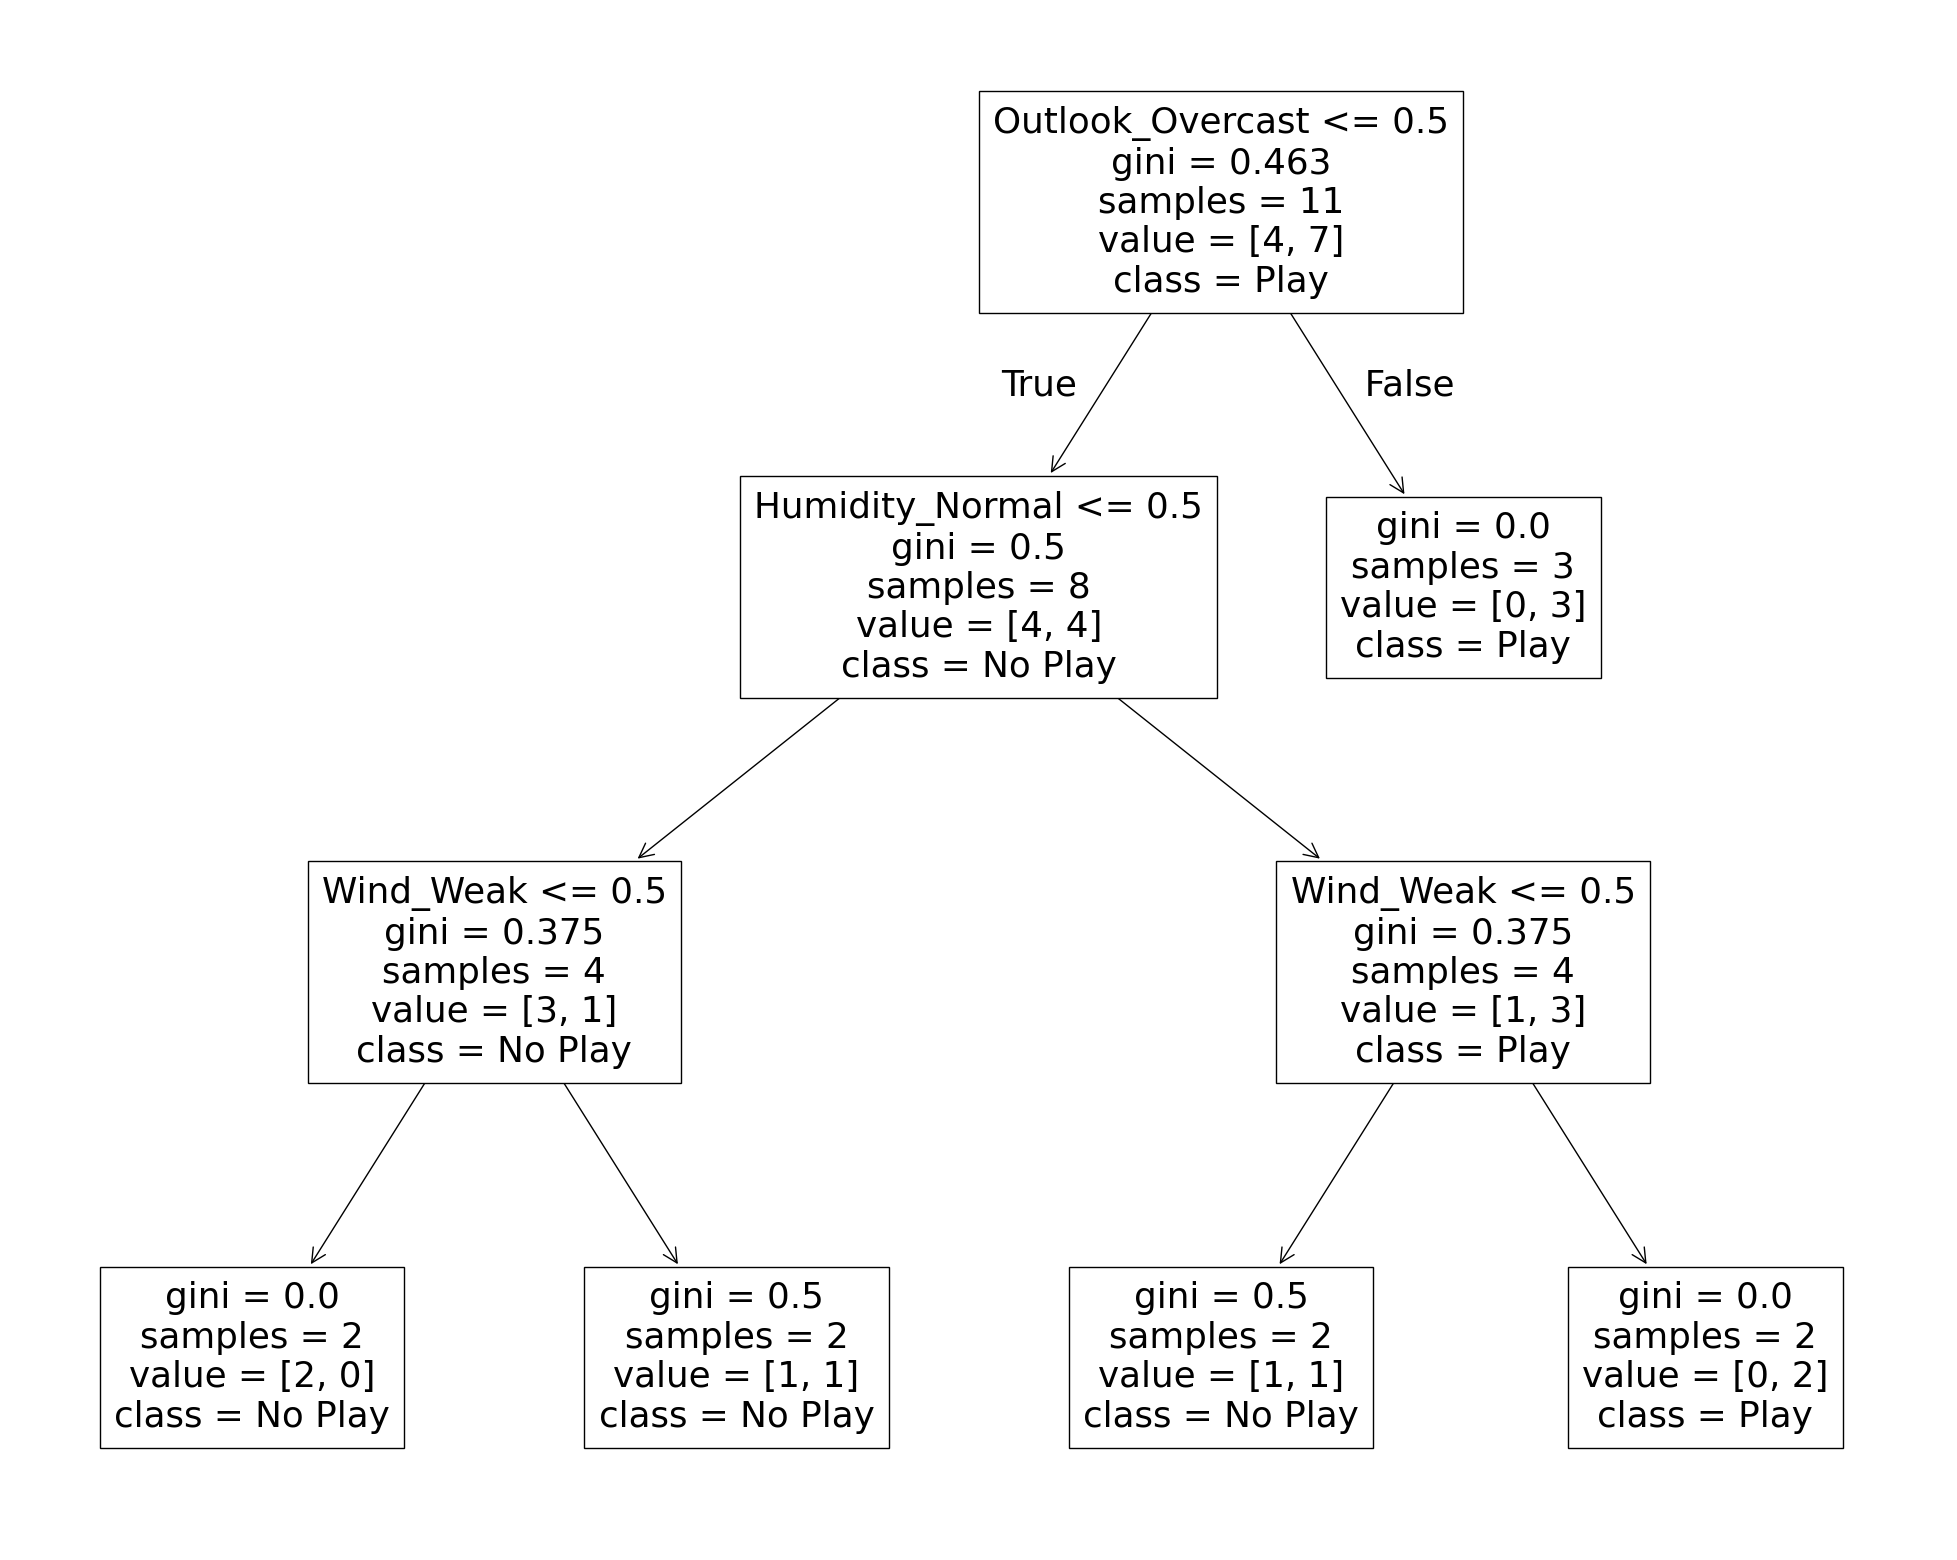

In [36]:
# visualize the tree
plt.figure(figsize=(25,20))
plot_tree(model, feature_names = X.columns, class_names = ['No Play', 'Play'])
plt.show()

In [37]:
# Make prediction
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1 0]
 [0 2]]
              precision    recall  f1-score   support

          No       1.00      1.00      1.00         1
         Yes       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



# Random Forest Classifier

In [38]:
from sklearn.ensemble import RandomForestClassifier

In [46]:
model = RandomForestClassifier(n_estimators = 20, random_state = 42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

In [47]:
# Print confusion matrix and classification report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1 0]
 [1 1]]
              precision    recall  f1-score   support

          No       0.50      1.00      0.67         1
         Yes       1.00      0.50      0.67         2

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



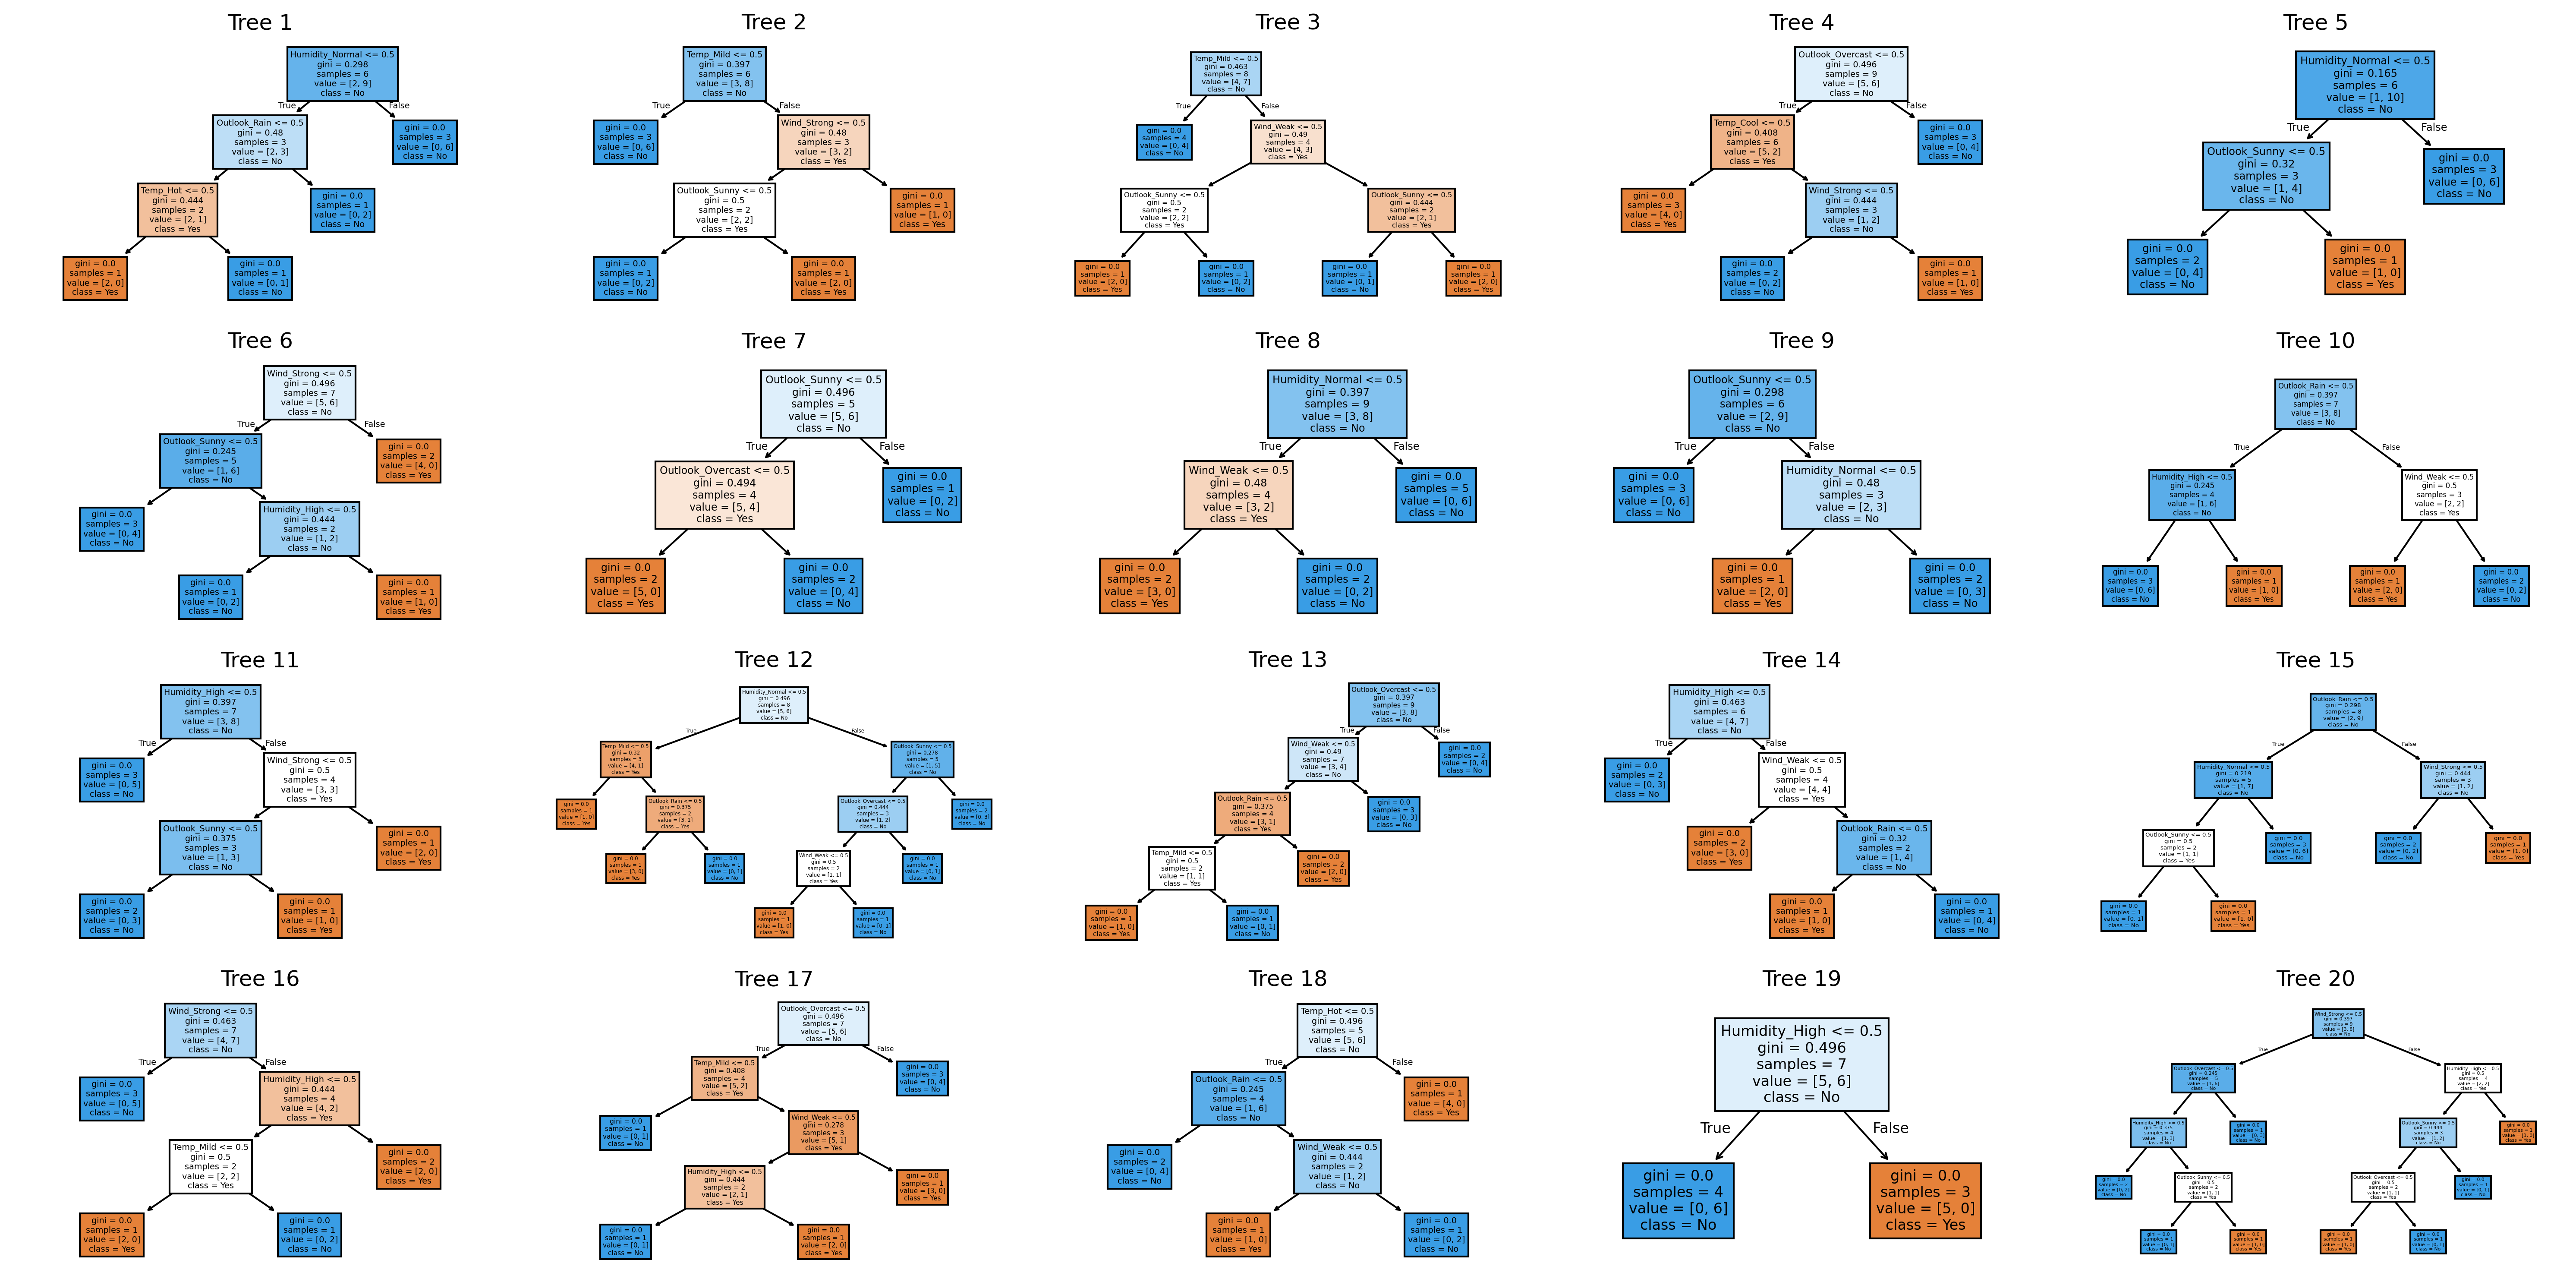

In [48]:
# Set up the figure with appropriate dimensions
num_trees = len(model.estimators_)
cols = 5
rows = (num_trees + cols - 1) // cols

fig,axes = plt.subplots(rows, cols, figsize=(20,10), dpi = 300)
axes = axes.flatten()

# Visualize each decision tree in the Random Forest
for i, tree in enumerate(model.estimators_):
    plot_tree(tree, feature_names= X.columns, class_names=['Yes', 'No'], filled=True, ax=axes[i])
    axes[i].set_title(f"Tree {i+1}")

# Remove unused subplots
for j in range(i+1, num_trees):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()